# Cross-Basin TC Forecasting: Model Comparison (Extended)

Side-by-side evaluation of **eight architectures** trained on WP, evaluated on SP:

**Original models:**
- FNO (Fourier Neural Operator) — baseline spectral approach
- ResNet-152 — standard CNN baseline
- U-Net with SE attention — spatial encoder-decoder

**New architectures (post-TA meeting):**
- U-Net + FiLM — temporal conditioning via FiLM layers
- FNO v2 — padded spectral convolutions + FiLM
- U-FNO — gated hybrid combining spectral + U-Net branches
- PI-GAN — physics-informed GAN with U-Net+FiLM generator
- SCANet — Spectral Cross-Attention Network: spectral + depthwise-sep local branches, context cross-attention, physics-informed auxiliary loss (Optuna-tuned)

Each model has a **WP-trained** checkpoint and a **fine-tuned** (WP→SP) checkpoint.

## 1. Setup & Data Loading

In [27]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, accuracy_score
)
from pathlib import Path
from collections import Counter
import warnings, os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)

# ── Paths ──
PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
EXP_DIR  = PROJECT_ROOT / "checkpoints"
FIG_DIR  = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64

N_DIR_CLASSES = 8
N_INT_CLASSES = 4
DIR_LABELS  = ["E", "SE", "S", "SW", "W", "NW", "N", "NE"]
INTE_LABELS = ["Weakening", "Steady", "Slow-intens.", "Rapid-intens."]

print(f"Device: {DEVICE}")

Device: cuda


In [28]:
# ── Dataset (shared across all models) ──
class CycloneDataset(Dataset):
    """Flattens storm-level dicts into timestep-level samples.
    Filters sentinel labels (-1). 1D features z-scored with WP train stats.
    Returns 6-tuple: (grid, env, d1d, time_feat, dir_lbl, int_lbl)."""
    def __init__(self, grids, env, data1d, labels, time_feats=None,
                 use_reflected=False, d1d_mean=None, d1d_std=None):
        self.samples = []
        dir_key = "direction_reflected" if use_reflected else "direction"
        for storm_id in grids:
            g = grids[storm_id]
            e = env[storm_id]
            d = data1d[storm_id]
            t = time_feats[storm_id] if time_feats else torch.zeros(g.shape[0], 6)
            d_lbl = labels[storm_id][dir_key]
            i_lbl = labels[storm_id]["intensity"]
            for idx in range(g.shape[0]):
                if d_lbl[idx].item() == -1 or i_lbl[idx].item() == -1:
                    continue
                self.samples.append((
                    g[idx], e[idx], d[idx], t[idx],
                    d_lbl[idx].long(), i_lbl[idx].long()))
        if d1d_mean is None:
            all_1d = torch.stack([s[2] for s in self.samples])
            self.d1d_mean = all_1d.mean(dim=0)
            self.d1d_std  = all_1d.std(dim=0).clamp(min=1e-6)
        else:
            self.d1d_mean, self.d1d_std = d1d_mean, d1d_std

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        grid, env, d1d, tf, dir_lbl, int_lbl = self.samples[idx]
        d1d = (d1d - self.d1d_mean) / self.d1d_std
        return grid, env, d1d, tf, dir_lbl, int_lbl


# ── Load splits (with time features) ──
SPLITS = {
    "wp_train":    {"reflected": False},
    "wp_val":      {"reflected": False},
    "sp_test":     {"reflected": True},
    "sp_ft_train": {"reflected": True},
    "sp_ft_val":   {"reflected": True},
}

raw = {}
for split in SPLITS:
    raw[split] = {
        "grids":  torch.load(DATA_DIR / "grids"  / f"{split}_grids.pt",  weights_only=False),
        "env":    torch.load(DATA_DIR / "env"     / f"{split}_env.pt",    weights_only=False),
        "data1d": torch.load(DATA_DIR / "data1d"  / f"{split}_1d.pt",    weights_only=False),
        "labels": torch.load(DATA_DIR / "labels"  / f"{split}_labels.pt", weights_only=False),
    }
    # Load time features if available
    time_path = DATA_DIR / "time" / f"{split}_time.pt"
    if time_path.exists():
        raw[split]["time"] = torch.load(time_path, weights_only=False)
    else:
        raw[split]["time"] = None

datasets = {}
datasets["wp_train"] = CycloneDataset(
    raw["wp_train"]["grids"], raw["wp_train"]["env"],
    raw["wp_train"]["data1d"], raw["wp_train"]["labels"],
    raw["wp_train"]["time"])
d1d_mean = datasets["wp_train"].d1d_mean
d1d_std  = datasets["wp_train"].d1d_std

for split, cfg in SPLITS.items():
    if split == "wp_train":
        continue
    datasets[split] = CycloneDataset(
        raw[split]["grids"], raw[split]["env"], raw[split]["data1d"],
        raw[split]["labels"], raw[split]["time"],
        use_reflected=cfg["reflected"],
        d1d_mean=d1d_mean, d1d_std=d1d_std)

loaders = {}
for split in SPLITS:
    loaders[split] = DataLoader(
        datasets[split], batch_size=BATCH_SIZE, shuffle=False,
        num_workers=0, pin_memory=True)

for s, ds in datasets.items():
    print(f"  {s:15s}: {len(ds):5d} samples")

  wp_train       :  1816 samples
  wp_val         :   535 samples
  sp_test        :   367 samples
  sp_ft_train    :   354 samples
  sp_ft_val      :    81 samples


## 2. Model Definitions

Each architecture is defined below with the **exact same structure** used during training, so that saved checkpoints can be loaded directly.

In [29]:
# ═══════════════════════════════════════════════════════════════
# FNO baseline
# ═══════════════════════════════════════════════════════════════

class SpectralConv2d(nn.Module):
    """2D Fourier spectral convolution (no padding)."""
    def __init__(self, in_ch, out_ch, modes1, modes2):
        super().__init__()
        self.modes1, self.modes2, self.out_channels = modes1, modes2, out_ch
        s = (2 / (in_ch + out_ch)) ** 0.5
        self.w1 = nn.Parameter(s * (torch.rand(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat) - 0.5))
        self.w2 = nn.Parameter(s * (torch.rand(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat) - 0.5))

    def forward(self, x):
        B, C, H, W = x.shape
        xf = torch.fft.rfft2(x)
        of = torch.zeros(B, self.out_channels, H, W // 2 + 1, dtype=torch.cfloat, device=x.device)
        of[:, :, :self.modes1, :self.modes2] = torch.einsum("bixy,ioxy->boxy", xf[:, :, :self.modes1, :self.modes2], self.w1)
        of[:, :, -self.modes1:, :self.modes2] = torch.einsum("bixy,ioxy->boxy", xf[:, :, -self.modes1:, :self.modes2], self.w2)
        return torch.fft.irfft2(of, s=(H, W))


class FNO2dClassifier(nn.Module):
    """FNO baseline — keys: spectral.X.w1/w2, skip.X, norms.X, proj.0"""
    def __init__(self, in_channels=15, hidden_channels=64, n_modes=15,
                 n_layers=4, n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 head_dim=128, dropout=0.1):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d
        self.lifting = nn.Sequential(nn.Conv2d(in_channels, hidden_channels, 1), nn.GELU())
        self.spectral = nn.ModuleList()
        self.skip = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(n_layers):
            self.spectral.append(SpectralConv2d(hidden_channels, hidden_channels, n_modes, n_modes))
            self.skip.append(nn.Conv2d(hidden_channels, hidden_channels, 1))
            self.norms.append(nn.BatchNorm2d(hidden_channels))
        self.proj = nn.Sequential(nn.Conv2d(hidden_channels, hidden_channels, 1), nn.GELU())
        aux = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        h_in = hidden_channels + aux
        self.head_dir = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(head_dim, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(head_dim, n_int_classes))

    def forward(self, grid, env=None, d1d=None):
        x = self.lifting(grid)
        for sp, sk, bn in zip(self.spectral, self.skip, self.norms):
            x = F.gelu(bn(sp(x) + sk(x)))
        x = self.proj(x).mean(dim=(-2, -1))
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d and d1d is not None: parts.append(d1d)
        x = torch.cat(parts, -1)
        return self.head_dir(x), self.head_int(x)

print("✓ FNO baseline defined")

✓ FNO baseline defined


In [30]:
# ═══════════════════════════════════════════════════════════════
# ResNet-152
# ═══════════════════════════════════════════════════════════════
import torchvision.models as tv_models

class ResNetClassifier(nn.Module):
    FEAT_DIMS = {"resnet18": 512, "resnet34": 512, "resnet50": 2048, "resnet152": 2048}

    def __init__(self, resnet_size="resnet152", in_channels=15,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 head_dim=128, dropout=0.25):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d
        backbone = getattr(tv_models, resnet_size)(weights=None)
        self.conv1 = nn.Conv2d(in_channels, 64, 3, stride=1, padding=1, bias=False)
        self.bn1 = backbone.bn1
        self.act = nn.GELU()
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.gap = nn.AdaptiveAvgPool2d(1)
        feat = self.FEAT_DIMS[resnet_size]
        aux = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        h_in = feat + aux
        self.head_dir = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_int_classes))

    def forward(self, grid, env=None, d1d=None):
        x = self.act(self.bn1(self.conv1(grid)))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        x = self.gap(x).flatten(1)
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d and d1d is not None: parts.append(d1d)
        x = torch.cat(parts, -1)
        return self.head_dir(x), self.head_int(x)

print("✓ ResNet-152 defined")

✓ ResNet-152 defined


In [31]:
# ═══════════════════════════════════════════════════════════════
# U-Net baseline (with SE attention)
# ═══════════════════════════════════════════════════════════════

class ConvBlock(nn.Module):
    """conv1→bn1→GELU→conv2→bn2→GELU + residual"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        h = F.gelu(self.bn1(self.conv1(x)))
        h = F.gelu(self.bn2(self.conv2(h)))
        return h + self.residual(x)


class SEBlock(nn.Module):
    def __init__(self, ch, r=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, max(ch // r, 4)), nn.GELU(),
            nn.Linear(max(ch // r, 4), ch), nn.Sigmoid())
    def forward(self, x):
        return x * self.fc(x).unsqueeze(-1).unsqueeze(-1)


class UNet2dClassifier(nn.Module):
    """U-Net with separate encoders/se_blocks/ups/decoders ModuleLists."""
    def __init__(self, in_channels=15, base_channels=32, n_levels=5,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 head_dim=256, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d
        self.n_levels = n_levels
        # Encoders + SE + pools
        self.encoders = nn.ModuleList()
        self.se_blocks = nn.ModuleList()
        ch = in_channels
        for i in range(n_levels):
            out = base_channels * (2 ** i)
            self.encoders.append(ConvBlock(ch, out))
            self.se_blocks.append(SEBlock(out))
            ch = out
        # Bottleneck
        bneck = base_channels * (2 ** n_levels)
        self.bottleneck = ConvBlock(ch, bneck)
        # Decoders + ups
        self.ups = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = bneck
        for i in range(n_levels - 1, -1, -1):
            skip_ch = base_channels * (2 ** i)
            self.ups.append(nn.ConvTranspose2d(ch, ch, 2, stride=2))
            self.decoders.append(ConvBlock(ch + skip_ch, skip_ch))
            ch = skip_ch
        self.gap = nn.AdaptiveAvgPool2d(1)
        aux = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        h_in = base_channels + aux
        self.head_dir = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(head_dim // 2, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(head_dim // 2, n_int_classes))

    def forward(self, grid, env=None, d1d=None):
        skips, x = [], grid
        for enc, se in zip(self.encoders, self.se_blocks):
            x = se(enc(x))
            skips.append(x)
            x = F.max_pool2d(x, 2, ceil_mode=True)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.ups, self.decoders, reversed(skips)):
            x = up(x)
            dh, dw = x.size(2) - skip.size(2), x.size(3) - skip.size(3)
            if dh > 0 or dw > 0:
                x = x[:, :, dh//2:dh//2+skip.size(2), dw//2:dw//2+skip.size(3)]
            elif dh < 0 or dw < 0:
                x = F.pad(x, [0, -dw, 0, -dh])
            x = dec(torch.cat([x, skip], 1))
        x = self.gap(x).flatten(1)
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d and d1d is not None: parts.append(d1d)
        f = torch.cat(parts, 1)
        return self.head_dir(f), self.head_int(f)

print("✓ U-Net baseline defined")

✓ U-Net baseline defined


In [32]:
# ═══════════════════════════════════════════════════════════════
# U-Net + FiLM (temporal conditioning) — shared FiLMLayer
# ═══════════════════════════════════════════════════════════════

class FiLMLayer(nn.Module):
    """Single-Linear FiLM: fc → chunk into gamma, beta."""
    def __init__(self, cond_dim, ch):
        super().__init__()
        self.fc = nn.Linear(cond_dim, ch * 2)
        nn.init.zeros_(self.fc.weight); nn.init.zeros_(self.fc.bias)
        self.fc.bias.data[:ch] = 1.0
    def forward(self, x, c):
        g, b = self.fc(c).chunk(2, 1)
        return g.unsqueeze(-1).unsqueeze(-1) * x + b.unsqueeze(-1).unsqueeze(-1)


class FiLMConvBlock(nn.Module):
    """conv1→bn1→GELU→conv2→bn2→FiLM→GELU + residual"""
    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.film = FiLMLayer(cond_dim, out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x, cond):
        h = F.gelu(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        h = F.gelu(self.film(h, cond))
        return h + self.residual(x)


class UNetFiLM2dClassifier(nn.Module):
    """U-Net+FiLM — keys: encoders.X.{conv1,bn1,conv2,bn2,film.fc,residual}, se_blocks, ups, decoders, bottleneck"""
    def __init__(self, in_channels=15, base_channels=48, n_levels=3,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 time_dim=6, time_emb_dim=64,
                 head_dim=512, dropout=0.0, drop_path=0.0):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_emb_dim), nn.GELU(),
            nn.Linear(time_emb_dim, time_emb_dim))
        # Encoders + SE
        self.encoders = nn.ModuleList()
        self.se_blocks = nn.ModuleList()
        ch = in_channels
        for i in range(n_levels):
            out = base_channels * (2 ** i)
            self.encoders.append(FiLMConvBlock(ch, out, time_emb_dim))
            self.se_blocks.append(SEBlock(out))
            ch = out
        # Bottleneck
        bneck = base_channels * (2 ** n_levels)
        self.bottleneck = FiLMConvBlock(ch, bneck, time_emb_dim)
        # Decoders + ups
        self.ups = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = bneck
        for i in range(n_levels - 1, -1, -1):
            skip_ch = base_channels * (2 ** i)
            self.ups.append(nn.ConvTranspose2d(ch, ch, 2, stride=2))
            self.decoders.append(FiLMConvBlock(ch + skip_ch, skip_ch, time_emb_dim))
            ch = skip_ch
        self.gap = nn.AdaptiveAvgPool2d(1)
        aux = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        h_in = base_channels + aux
        self.head_dir = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(head_dim // 2, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(head_dim // 2, n_int_classes))

    def forward(self, grid, env=None, d1d=None, time_feat=None):
        t = self.time_mlp(time_feat)
        skips, x = [], grid
        for enc, se in zip(self.encoders, self.se_blocks):
            x = se(enc(x, t))
            skips.append(x)
            x = F.max_pool2d(x, 2, ceil_mode=True)
        x = self.bottleneck(x, t)
        for up, dec, skip in zip(self.ups, self.decoders, reversed(skips)):
            x = up(x)
            dh, dw = x.size(2) - skip.size(2), x.size(3) - skip.size(3)
            if dh > 0 or dw > 0:
                x = x[:, :, dh//2:dh//2+skip.size(2), dw//2:dw//2+skip.size(3)]
            elif dh < 0 or dw < 0:
                x = F.pad(x, [0, -dw, 0, -dh])
            x = dec(torch.cat([x, skip], 1), t)
        x = self.gap(x).flatten(1)
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d and d1d is not None: parts.append(d1d)
        f = torch.cat(parts, 1)
        return self.head_dir(f), self.head_int(f)

print("✓ U-Net+FiLM defined")

✓ U-Net+FiLM defined


In [33]:
# ═══════════════════════════════════════════════════════════════
# FNO v2 (padded spectral conv + FiLM time conditioning)
# ═══════════════════════════════════════════════════════════════

class PaddedSpectralConv2d(nn.Module):
    """2D Fourier spectral conv with reflect padding."""
    def __init__(self, in_ch, out_ch, modes1, modes2, padding=9):
        super().__init__()
        self.modes1, self.modes2, self.out_channels, self.padding = modes1, modes2, out_ch, padding
        s = (2 / (in_ch + out_ch)) ** 0.5
        self.w1 = nn.Parameter(s * (torch.rand(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat) - 0.5))
        self.w2 = nn.Parameter(s * (torch.rand(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat) - 0.5))

    def forward(self, x):
        B, C, H, W = x.shape
        if self.padding > 0:
            x = F.pad(x, [self.padding] * 4, mode='reflect')
        Hp, Wp = x.shape[-2], x.shape[-1]
        xf = torch.fft.rfft2(x)
        of = torch.zeros(B, self.out_channels, Hp, Wp // 2 + 1, dtype=torch.cfloat, device=x.device)
        of[:, :, :self.modes1, :self.modes2] = torch.einsum("bixy,ioxy->boxy", xf[:, :, :self.modes1, :self.modes2], self.w1)
        of[:, :, -self.modes1:, :self.modes2] = torch.einsum("bixy,ioxy->boxy", xf[:, :, -self.modes1:, :self.modes2], self.w2)
        x = torch.fft.irfft2(of, s=(Hp, Wp))
        if self.padding > 0:
            x = x[:, :, self.padding:-self.padding, self.padding:-self.padding]
        return x


class FNO2dFiLMClassifier(nn.Module):
    """FNO v2 — keys: spectral.X.w1/w2, skip.X, norms.X, films.X.fc, proj.0"""
    def __init__(self, in_channels=15, hidden_channels=48, n_modes=20,
                 n_layers=5, padding=9,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 time_dim=6, time_emb_dim=64, head_dim=128, dropout=0.1):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_emb_dim), nn.GELU(),
            nn.Linear(time_emb_dim, time_emb_dim), nn.GELU())
        self.lifting = nn.Sequential(nn.Conv2d(in_channels, hidden_channels, 1), nn.GELU())
        self.spectral = nn.ModuleList()
        self.skip = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.films = nn.ModuleList()
        for _ in range(n_layers):
            self.spectral.append(PaddedSpectralConv2d(hidden_channels, hidden_channels, n_modes, n_modes, padding))
            self.skip.append(nn.Conv2d(hidden_channels, hidden_channels, 1))
            self.norms.append(nn.BatchNorm2d(hidden_channels))
            self.films.append(FiLMLayer(time_emb_dim, hidden_channels))
        self.proj = nn.Sequential(nn.Conv2d(hidden_channels, hidden_channels, 1), nn.GELU())
        aux = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        h_in = hidden_channels + aux
        self.head_dir = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(head_dim, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(head_dim, n_int_classes))

    def forward(self, grid, env=None, d1d=None, time_feat=None):
        t_emb = self.time_mlp(time_feat) if time_feat is not None else None
        x = self.lifting(grid)
        for sp, sk, bn, film in zip(self.spectral, self.skip, self.norms, self.films):
            x_out = bn(sp(x) + sk(x))
            if t_emb is not None:
                x_out = film(x_out, t_emb)
            x = F.gelu(x_out)
        x = self.proj(x).mean(dim=(-2, -1))
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d and d1d is not None: parts.append(d1d)
        x = torch.cat(parts, -1)
        return self.head_dir(x), self.head_int(x)

print("✓ FNO v2 defined")

✓ FNO v2 defined


In [34]:
# ═══════════════════════════════════════════════════════════════
# U-FNO (gated hybrid: spectral + U-Net branch)
# ═══════════════════════════════════════════════════════════════

class UNetBranch(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.down = nn.Sequential(nn.Conv2d(ch, ch, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(ch), nn.GELU())
        self.mid = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.GELU())
        self.up = nn.ConvTranspose2d(ch, ch, 2, stride=2)
        self.fuse = nn.Sequential(nn.Conv2d(ch * 2, ch, 1, bias=False), nn.BatchNorm2d(ch))
    def forward(self, x):
        skip = x
        x = self.down(x)
        x = self.mid(x)
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.fuse(torch.cat([x, skip], 1))


class GateParam(nn.Module):
    """Wraps a Parameter as gate.w to match checkpoint keys."""
    def __init__(self, n=3):
        super().__init__()
        self.w = nn.Parameter(torch.ones(n) / n)


class UFNOBlock(nn.Module):
    def __init__(self, ch, modes, padding, time_emb_dim, dropout=0.1):
        super().__init__()
        self.spectral = PaddedSpectralConv2d(ch, ch, modes, modes, padding)
        self.unet = UNetBranch(ch)
        self.residual = nn.Conv2d(ch, ch, 1)
        self.gate = GateParam(3)
        self.norm = nn.BatchNorm2d(ch)
        self.film = FiLMLayer(time_emb_dim, ch)
        self.dropout = nn.Dropout2d(dropout)
    def forward(self, x, t_emb):
        g = F.softmax(self.gate.w, dim=0)
        out = g[0] * self.spectral(x) + g[1] * self.unet(x) + g[2] * self.residual(x)
        out = self.norm(out)
        if t_emb is not None:
            out = self.film(out, t_emb)
        out = self.dropout(F.gelu(out))
        return out + x


class UFNO2dClassifier(nn.Module):
    """U-FNO — keys: blocks.X.{spectral,unet,residual,gate.w,norm,film.fc}, proj.0"""
    def __init__(self, in_ch=15, hidden_ch=48, n_modes=16, n_layers=2, padding=9,
                 n_dir=8, n_int=4, env_dim=40, d1d_dim=4,
                 use_env=True, use_1d=True, time_dim=6, time_emb_dim=64,
                 head_dim=128, dropout=0.1):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_emb_dim), nn.GELU(),
            nn.Linear(time_emb_dim, time_emb_dim))
        self.lifting = nn.Sequential(nn.Conv2d(in_ch, hidden_ch, 1), nn.GELU())
        self.blocks = nn.ModuleList([
            UFNOBlock(hidden_ch, n_modes, padding, time_emb_dim, dropout)
            for _ in range(n_layers)])
        self.proj = nn.Sequential(nn.Conv2d(hidden_ch, hidden_ch, 1), nn.GELU())
        aux = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        h_in = hidden_ch + aux
        self.head_dir = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(head_dim // 2, n_dir))
        self.head_int = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(head_dim // 2, n_int))

    def forward(self, grid, env=None, d1d=None, time_feat=None):
        t = self.time_mlp(time_feat) if time_feat is not None else None
        x = self.lifting(grid)
        for blk in self.blocks:
            x = blk(x, t)
        x = self.proj(x).mean(dim=(-2, -1))
        parts = [x]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d and d1d is not None: parts.append(d1d)
        x = torch.cat(parts, -1)
        return self.head_dir(x), self.head_int(x)

print("✓ U-FNO defined")

✓ U-FNO defined


In [35]:
# ═══════════════════════════════════════════════════════════════
# PI-GAN Generator (physics-informed GAN with U-Net+FiLM backbone)
# ═══════════════════════════════════════════════════════════════

class PIGANConvBlock(nn.Module):
    """conv1→bn1→GELU→conv2→bn2→FiLM→GELU + residual"""
    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.film = FiLMLayer(cond_dim, out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x, cond):
        h = F.gelu(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        h = F.gelu(self.film(h, cond))
        return h + self.residual(x)


class PIGANEncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        self.conv = PIGANConvBlock(in_ch, out_ch, cond_dim)
        self.se = SEBlock(out_ch)
        self.pool = nn.MaxPool2d(2, ceil_mode=True)
    def forward(self, x, cond):
        skip = self.se(self.conv(x, cond))
        return skip, self.pool(skip)


class PIGANDecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, cond_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch, 2, stride=2)
        self.conv = PIGANConvBlock(in_ch + skip_ch, out_ch, cond_dim)
    def forward(self, x, skip, cond):
        x = self.up(x)
        dh, dw = x.size(2) - skip.size(2), x.size(3) - skip.size(3)
        if dh > 0 or dw > 0:
            x = x[:, :, dh//2:dh//2+skip.size(2), dw//2:dw//2+skip.size(3)]
        elif dh < 0 or dw < 0:
            x = F.pad(x, [0, -dw, 0, -dh])
        return self.conv(torch.cat([x, skip], 1), cond)


class PIGANGenerator(nn.Module):
    """PI-GAN generator: U-Net+FiLM + physics reconstruction head."""
    def __init__(self, in_channels=15, base_channels=32, n_levels=4,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 time_dim=6, time_emb_dim=64, head_dim=256, dropout=0.2):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_emb_dim), nn.GELU(),
            nn.Linear(time_emb_dim, time_emb_dim))
        # Encoder
        self.encoders = nn.ModuleList()
        ch = in_channels
        for i in range(n_levels):
            out = base_channels * (2 ** i)
            self.encoders.append(PIGANEncoderBlock(ch, out, time_emb_dim))
            ch = out
        # Bottleneck
        bneck = base_channels * (2 ** n_levels)
        self.bottleneck = PIGANConvBlock(ch, bneck, time_emb_dim)
        # Decoder
        self.decoders = nn.ModuleList()
        ch = bneck
        for i in range(n_levels - 1, -1, -1):
            skip_ch = base_channels * (2 ** i)
            self.decoders.append(PIGANDecoderBlock(ch, skip_ch, skip_ch, time_emb_dim))
            ch = skip_ch
        # Classification heads
        self.gap = nn.AdaptiveAvgPool2d(1)
        aux = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        h_in = base_channels + aux
        self.head_dir = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(h_in, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_int_classes))
        # Physics reconstruction head (first Conv2d has no bias)
        self.physics_head = nn.Sequential(
            nn.Conv2d(base_channels, 16, 3, padding=1, bias=False),
            nn.BatchNorm2d(16), nn.GELU(),
            nn.Conv2d(16, 4, 1))

    def forward(self, grid, env=None, d1d=None, time_feat=None):
        t = self.time_mlp(time_feat)
        skips, x = [], grid
        for enc in self.encoders:
            skip, x = enc(x, t)
            skips.append(skip)
        x = self.bottleneck(x, t)
        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip, t)
        # Classification
        feat = self.gap(x).flatten(1)
        parts = [feat]
        if self.use_env and env is not None: parts.append(env)
        if self.use_1d and d1d is not None: parts.append(d1d)
        fused = torch.cat(parts, 1)
        return self.head_dir(fused), self.head_int(fused)

print("✓ PI-GAN Generator defined")

✓ PI-GAN Generator defined


In [36]:
# ═══════════════════════════════════════════════════════════════
# SCANet — Spectral Cross-Attention Network (Optuna-tuned)
# ═══════════════════════════════════════════════════════════════
# Combines: AFNO-style spectral conv, depthwise-sep local conv,
# cross-attention context modulation, physics auxiliary head.
# References: FourCastNet, Perceiver, NeuralGCM, MobileNet, ClimaX

class SCANetSpectralConv2d(nn.Module):
    """2D Fourier spectral conv with reflect padding."""
    def __init__(self, in_ch, out_ch, modes1, modes2, padding=9):
        super().__init__()
        self.modes1, self.modes2, self.out_channels, self.padding = modes1, modes2, out_ch, padding
        s = (2 / (in_ch + out_ch)) ** 0.5
        self.w1 = nn.Parameter(s * (torch.rand(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat) - 0.5))
        self.w2 = nn.Parameter(s * (torch.rand(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat) - 0.5))

    def forward(self, x):
        B, C, H, W = x.shape
        if self.padding > 0:
            x = F.pad(x, [self.padding] * 4, mode='reflect')
        Hp, Wp = x.shape[-2], x.shape[-1]
        xf = torch.fft.rfft2(x)
        of = torch.zeros(B, self.out_channels, Hp, Wp // 2 + 1, dtype=torch.cfloat, device=x.device)
        of[:, :, :self.modes1, :self.modes2] = torch.einsum(
            "bixy,ioxy->boxy", xf[:, :, :self.modes1, :self.modes2], self.w1)
        of[:, :, -self.modes1:, :self.modes2] = torch.einsum(
            "bixy,ioxy->boxy", xf[:, :, -self.modes1:, :self.modes2], self.w2)
        x = torch.fft.irfft2(of, s=(Hp, Wp))
        if self.padding > 0:
            x = x[:, :, self.padding:-self.padding, self.padding:-self.padding]
        return x


class ContextCrossAttention(nn.Module):
    """Single-head cross-attention: context queries spatial features."""
    def __init__(self, context_dim, channels):
        super().__init__()
        self.q_proj = nn.Linear(context_dim, channels)
        self.k_conv = nn.Conv2d(channels, channels, 1)
        self.v_conv = nn.Conv2d(channels, channels, 1)
        self.scale = channels ** -0.5
        nn.init.zeros_(self.q_proj.weight)
        nn.init.ones_(self.q_proj.bias)

    def forward(self, x, context):
        B, C, H, W = x.shape
        q = self.q_proj(context).unsqueeze(1)
        k = self.k_conv(x).reshape(B, C, -1).permute(0, 2, 1)
        v = self.v_conv(x).reshape(B, C, -1).permute(0, 2, 1)
        attn = torch.bmm(q, k.transpose(1, 2)) * self.scale
        attn = F.softmax(attn, dim=-1)
        out = torch.bmm(attn, v)
        gate = out.squeeze(1).unsqueeze(-1).unsqueeze(-1)
        return x * gate


class DepthwiseSepConv(nn.Module):
    """Depthwise-separable 5×5 conv for local spatial patterns."""
    def __init__(self, channels):
        super().__init__()
        self.dw = nn.Conv2d(channels, channels, 5, padding=2, groups=channels, bias=False)
        self.bn = nn.BatchNorm2d(channels)
        self.pw = nn.Conv2d(channels, channels, 1, bias=False)

    def forward(self, x):
        return self.pw(F.gelu(self.bn(self.dw(x))))


class SCANetBlock(nn.Module):
    """Spectral + local gated branches with context cross-attention."""
    def __init__(self, channels, modes, padding, context_dim, dropout=0.1):
        super().__init__()
        self.spectral = SCANetSpectralConv2d(channels, channels, modes, modes, padding)
        self.channel_mixer = nn.Conv2d(channels, channels, 1)
        self.local_conv = DepthwiseSepConv(channels)
        self.gate = nn.Parameter(torch.ones(2) / 2)
        self.cross_attn = ContextCrossAttention(context_dim, channels)
        self.norm = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x, context):
        g = F.softmax(self.gate, dim=0)
        spectral_out = self.channel_mixer(self.spectral(x))
        local_out = self.local_conv(x)
        out = g[0] * spectral_out + g[1] * local_out
        out = self.cross_attn(out, context)
        out = self.norm(out)
        out = self.dropout(F.gelu(out))
        return out + x


class SCANet(nn.Module):
    """Spectral Cross-Attention Network for TC classification."""
    def __init__(self, in_channels=15, hidden_ch=64, n_modes=12, n_blocks=3,
                 padding=9, n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, time_dim=6, context_dim=64,
                 use_env=True, use_1d=True,
                 head_dim=128, dropout=0.1):
        super().__init__()
        self.use_env, self.use_1d = use_env, use_1d
        # Context encoder
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, context_dim), nn.GELU(),
            nn.Linear(context_dim, context_dim))
        self.env_mlp = nn.Sequential(
            nn.Linear(env_dim, context_dim), nn.GELU(),
            nn.Linear(context_dim, context_dim))
        self.d1d_mlp = nn.Sequential(
            nn.Linear(d1d_dim, context_dim), nn.GELU(),
            nn.Linear(context_dim, context_dim))
        # Lifting
        self.lifting = nn.Sequential(nn.Conv2d(in_channels, hidden_ch, 1), nn.GELU())
        # SCANet blocks
        self.blocks = nn.ModuleList([
            SCANetBlock(hidden_ch, n_modes, padding, context_dim, dropout)
            for _ in range(n_blocks)
        ])
        # Projection + pooling
        self.projection = nn.Sequential(nn.Conv2d(hidden_ch, hidden_ch, 1), nn.GELU())
        # Classification heads
        fuse_dim = hidden_ch + context_dim
        self.head_dir = nn.Sequential(
            nn.Linear(fuse_dim, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_dir_classes))
        self.head_int = nn.Sequential(
            nn.Linear(fuse_dim, head_dim), nn.GELU(), nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_int_classes))
        # Physics head (needed for state_dict loading)
        self.physics_head = nn.Sequential(
            nn.Conv2d(hidden_ch, hidden_ch // 2, 3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_ch // 2), nn.GELU(),
            nn.Conv2d(hidden_ch // 2, 4, 1))

    def forward(self, grid, env=None, d1d=None, time_feat=None):
        context = self.time_mlp(time_feat)
        if self.use_env and env is not None:
            context = context + self.env_mlp(env)
        if self.use_1d and d1d is not None:
            context = context + self.d1d_mlp(d1d)
        x = self.lifting(grid)
        for blk in self.blocks:
            x = blk(x, context)
        feat_map = self.projection(x)
        physics_pred = self.physics_head(feat_map)
        pooled = feat_map.mean(dim=(-2, -1))
        fused = torch.cat([pooled, context], dim=-1)
        return self.head_dir(fused), self.head_int(fused), physics_pred

print(f"SCANet defined — test: {sum(p.numel() for p in SCANet(hidden_ch=64, n_modes=12, n_blocks=3, padding=13, context_dim=32, head_dim=192, dropout=0.2).parameters()):,d} params")

SCANet defined — test: 3,704,726 params


## 3. Load Checkpoints

In [37]:
def load_model(cls, ckpt_path, **kwargs):
    """Instantiate model and load state_dict."""
    model = cls(**kwargs)
    state = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    model.load_state_dict(state)
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  {cls.__name__:25s} | {n_params:>10,d} params | loaded from {ckpt_path.name}")
    return model


# ── WP-trained models (baseline) ──
print("WP-trained models (baseline, zero-shot):")
fno_wp = load_model(FNO2dClassifier, EXP_DIR / "fno_best_wp.pt",
                    in_channels=15, hidden_channels=64, n_modes=15, n_layers=4,
                    head_dim=128, dropout=0.1)
resnet_wp = load_model(ResNetClassifier, EXP_DIR / "resnet_best_wp.pt",
                       resnet_size="resnet152", in_channels=15,
                       head_dim=128, dropout=0.25)
unet_wp = load_model(UNet2dClassifier, EXP_DIR / "unet_best_wp.pt",
                     in_channels=15, base_channels=32, n_levels=5,
                     head_dim=256)

# ── WP-trained models (new architectures) ──
print("\nWP-trained models (new architectures):")
unet_film_wp = load_model(UNetFiLM2dClassifier, EXP_DIR / "unet_film_best_wp.pt",
                           in_channels=15, base_channels=48, n_levels=3,
                           head_dim=512, time_dim=6, time_emb_dim=64)
fno_v2_wp = load_model(FNO2dFiLMClassifier, EXP_DIR / "fno_v2_best_wp.pt",
                        in_channels=15, hidden_channels=48, n_modes=20,
                        n_layers=5, padding=9, time_dim=6, time_emb_dim=64,
                        head_dim=128, dropout=0.1)
ufno_wp = load_model(UFNO2dClassifier, EXP_DIR / "ufno_best_wp.pt",
                      in_ch=15, hidden_ch=48, n_modes=16, n_layers=2,
                      padding=9, time_dim=6, time_emb_dim=64,
                      head_dim=128, dropout=0.1)
pi_gan_wp = load_model(PIGANGenerator, EXP_DIR / "pi_gan_best_wp.pt",
                        in_channels=15, base_channels=32, n_levels=4,
                        head_dim=256, time_dim=6, time_emb_dim=64, dropout=0.2)
scanet_wp = load_model(SCANet, EXP_DIR / "scanet_best_wp.pt",
                        in_channels=15, hidden_ch=64, n_modes=12, n_blocks=3,
                        padding=13, context_dim=32, head_dim=192, dropout=0.2)

# ── Fine-tuned models (baseline) ──
print("\nFine-tuned models (baseline, SP):")
fno_ft = load_model(FNO2dClassifier, EXP_DIR / "fno_best_ft.pt",
                    in_channels=15, hidden_channels=64, n_modes=15, n_layers=4,
                    head_dim=128, dropout=0.1)
resnet_ft = load_model(ResNetClassifier, EXP_DIR / "resnet_best_ft.pt",
                       resnet_size="resnet152", in_channels=15,
                       head_dim=128, dropout=0.25)
unet_ft = load_model(UNet2dClassifier, EXP_DIR / "unet_best_ft.pt",
                     in_channels=15, base_channels=32, n_levels=5,
                     head_dim=256)

# ── Fine-tuned models (new architectures) ──
print("\nFine-tuned models (new architectures, SP):")
unet_film_ft = load_model(UNetFiLM2dClassifier, EXP_DIR / "unet_film_best_ft.pt",
                           in_channels=15, base_channels=48, n_levels=3,
                           head_dim=512, time_dim=6, time_emb_dim=64)
fno_v2_ft = load_model(FNO2dFiLMClassifier, EXP_DIR / "fno_v2_best_ft.pt",
                        in_channels=15, hidden_channels=48, n_modes=20,
                        n_layers=5, padding=9, time_dim=6, time_emb_dim=64,
                        head_dim=128, dropout=0.1)
ufno_ft = load_model(UFNO2dClassifier, EXP_DIR / "ufno_best_ft.pt",
                      in_ch=15, hidden_ch=48, n_modes=16, n_layers=2,
                      padding=9, time_dim=6, time_emb_dim=64,
                      head_dim=128, dropout=0.1)
pi_gan_ft = load_model(PIGANGenerator, EXP_DIR / "pi_gan_best_ft.pt",
                        in_channels=15, base_channels=32, n_levels=4,
                        head_dim=256, time_dim=6, time_emb_dim=64, dropout=0.2)
scanet_ft = load_model(SCANet, EXP_DIR / "scanet_best_ft.pt",
                        in_channels=15, hidden_ch=64, n_modes=12, n_blocks=3,
                        padding=13, context_dim=32, head_dim=192, dropout=0.2)

# ── Organize into dicts ──
MODEL_NAMES = ["FNO", "ResNet-152", "U-Net", "U-Net+FiLM", "FNO v2", "U-FNO", "PI-GAN", "SCANet"]
models_wp = [fno_wp, resnet_wp, unet_wp, unet_film_wp, fno_v2_wp, ufno_wp, pi_gan_wp, scanet_wp]
models_ft = [fno_ft, resnet_ft, unet_ft, unet_film_ft, fno_v2_ft, ufno_ft, pi_gan_ft, scanet_ft]
uses_time = [False, False, False, True, True, True, True, True]

print(f"\n✓ All {len(MODEL_NAMES)} × 2 models loaded successfully")

WP-trained models (baseline, zero-shot):
  FNO2dClassifier           |  7,424,588 params | loaded from fno_best_wp.pt
  ResNetClassifier          | 58,696,140 params | loaded from resnet_best_wp.pt
  UNet2dClassifier          | 39,070,052 params | loaded from unet_best_wp.pt

WP-trained models (new architectures):
  UNetFiLM2dClassifier      |  5,930,928 params | loaded from unet_film_best_wp.pt
  FNO2dFiLMClassifier       |  9,292,524 params | loaded from fno_v2_best_wp.pt
  UFNO2dClassifier          |  2,536,770 params | loaded from ufno_best_wp.pt
  PIGANGenerator            | 10,033,864 params | loaded from pi_gan_best_wp.pt
  SCANet                    |  3,704,726 params | loaded from scanet_best_wp.pt

Fine-tuned models (baseline, SP):
  FNO2dClassifier           |  7,424,588 params | loaded from fno_best_ft.pt
  ResNetClassifier          | 58,696,140 params | loaded from resnet_best_ft.pt
  UNet2dClassifier          | 39,070,052 params | loaded from unet_best_ft.pt

Fine-tuned m

## 4. Evaluation

In [38]:
@torch.no_grad()
def evaluate(model, loader, uses_time=False):
    """Returns dict with dir/int accuracy, macro-F1, and raw predictions."""
    model.eval()
    dir_preds, dir_trues = [], []
    int_preds, int_trues = [], []
    for batch in loader:
        grid, env, d1d, time_feat, dl, il = batch
        grid = grid.to(DEVICE)
        env  = env.to(DEVICE)
        d1d  = d1d.to(DEVICE)
        if uses_time:
            time_feat = time_feat.to(DEVICE)
            outputs = model(grid, env, d1d, time_feat=time_feat)
        else:
            outputs = model(grid, env, d1d)
        # Handle models returning 2 values (dir, int) or 3+ values (PI-GAN, SCANet)
        d_out, i_out = outputs[0], outputs[1]
        dir_preds.extend(d_out.argmax(1).cpu().tolist())
        int_preds.extend(i_out.argmax(1).cpu().tolist())
        dir_trues.extend(dl.tolist())
        int_trues.extend(il.tolist())
    return {
        "dir_acc": accuracy_score(dir_trues, dir_preds),
        "dir_f1":  f1_score(dir_trues, dir_preds, average="macro", zero_division=0),
        "int_acc": accuracy_score(int_trues, int_preds),
        "int_f1":  f1_score(int_trues, int_preds, average="macro", zero_division=0),
        "dir_preds": dir_preds, "dir_trues": dir_trues,
        "int_preds": int_preds, "int_trues": int_trues,
    }


# ── Model registry (all 8 architectures) ──
wp_models   = [fno_wp, resnet_wp, unet_wp, unet_film_wp, fno_v2_wp, ufno_wp, pi_gan_wp, scanet_wp]
ft_models   = [fno_ft, resnet_ft, unet_ft, unet_film_ft, fno_v2_ft, ufno_ft, pi_gan_ft, scanet_ft]

results = {}
for name, m_wp, m_ft, ut in zip(MODEL_NAMES, wp_models, ft_models, uses_time):
    results[name] = {}
    results[name]["WP Val"]        = evaluate(m_wp, loaders["wp_val"], uses_time=ut)
    results[name]["SP Zero-Shot"]  = evaluate(m_wp, loaders["sp_test"], uses_time=ut)
    results[name]["SP Fine-Tuned"] = evaluate(m_ft, loaders["sp_test"], uses_time=ut)
    print(f"{name:12s} | WP dir={results[name]['WP Val']['dir_acc']:.3f}  "
          f"SP-ZS dir={results[name]['SP Zero-Shot']['dir_acc']:.3f}  "
          f"SP-FT dir={results[name]['SP Fine-Tuned']['dir_acc']:.3f}")

FNO          | WP dir=0.364  SP-ZS dir=0.221  SP-FT dir=0.229
ResNet-152   | WP dir=0.499  SP-ZS dir=0.259  SP-FT dir=0.256
U-Net        | WP dir=0.600  SP-ZS dir=0.270  SP-FT dir=0.316
U-Net+FiLM   | WP dir=0.564  SP-ZS dir=0.324  SP-FT dir=0.384
FNO v2       | WP dir=0.366  SP-ZS dir=0.172  SP-FT dir=0.153
U-FNO        | WP dir=0.557  SP-ZS dir=0.346  SP-FT dir=0.308
PI-GAN       | WP dir=0.570  SP-ZS dir=0.362  SP-FT dir=0.264
SCANet       | WP dir=0.564  SP-ZS dir=0.433  SP-FT dir=0.381


## 5. Results Summary Table

In [39]:
import pandas as pd

# ── Build comparison table ──
rows = []
for name in MODEL_NAMES:
    for setting in ["WP Val", "SP Zero-Shot", "SP Fine-Tuned"]:
        m = results[name][setting]
        rows.append({
            "Model": name,
            "Setting": setting,
            "Dir Acc": m["dir_acc"],
            "Dir F1":  m["dir_f1"],
            "Int Acc": m["int_acc"],
            "Int F1":  m["int_f1"],
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format="{:.3f}".format))
df

     Model       Setting  Dir Acc  Dir F1  Int Acc  Int F1
       FNO        WP Val    0.364   0.140    0.417   0.341
       FNO  SP Zero-Shot    0.221   0.125    0.270   0.186
       FNO SP Fine-Tuned    0.229   0.165    0.341   0.276
ResNet-152        WP Val    0.499   0.372    0.611   0.501
ResNet-152  SP Zero-Shot    0.259   0.211    0.322   0.242
ResNet-152 SP Fine-Tuned    0.256   0.213    0.496   0.423
     U-Net        WP Val    0.600   0.419    0.589   0.479
     U-Net  SP Zero-Shot    0.270   0.191    0.313   0.207
     U-Net SP Fine-Tuned    0.316   0.240    0.439   0.347
U-Net+FiLM        WP Val    0.564   0.404    0.574   0.472
U-Net+FiLM  SP Zero-Shot    0.324   0.274    0.409   0.335
U-Net+FiLM SP Fine-Tuned    0.384   0.271    0.444   0.386
    FNO v2        WP Val    0.366   0.124    0.445   0.237
    FNO v2  SP Zero-Shot    0.172   0.047    0.398   0.198
    FNO v2 SP Fine-Tuned    0.153   0.091    0.351   0.219
     U-FNO        WP Val    0.557   0.404    0.630   0.4

,Model,Setting,Dir Acc,Dir F1,Int Acc,Int F1
0,FNO,WP Val,0.364486,0.139951,0.416822,0.340839
1,FNO,SP Zero-Shot,0.220708,0.125492,0.269755,0.186221
2,FNO,SP Fine-Tuned,0.228883,0.165003,0.340599,0.275916
3,ResNet-152,WP Val,0.499065,0.371932,0.611215,0.500701
4,ResNet-152,SP Zero-Shot,0.258856,0.210547,0.321526,0.242325
5,ResNet-152,SP Fine-Tuned,0.256131,0.213010,0.495913,0.423313
6,U-Net,WP Val,0.600000,0.418972,0.588785,0.478509
7,U-Net,SP Zero-Shot,0.269755,0.190976,0.313351,0.206710
8,U-Net,SP Fine-Tuned,0.316076,0.240309,0.438692,0.346892
9,U-Net+FiLM,WP Val,0.564486,0.404095,0.573832,0.471912


In [40]:
# ── Transfer gap & fine-tuning recovery ──
gap_rows = []
for name in MODEL_NAMES:
    wp  = results[name]["WP Val"]["dir_acc"]
    zs  = results[name]["SP Zero-Shot"]["dir_acc"]
    ft  = results[name]["SP Fine-Tuned"]["dir_acc"]
    gap_rows.append({
        "Model": name,
        "WP Val Dir Acc": wp,
        "SP Zero-Shot Dir Acc": zs,
        "Transfer Gap": zs - wp,
        "SP Fine-Tuned Dir Acc": ft,
        "FT Recovery": ft - zs,
    })

df_gap = pd.DataFrame(gap_rows)
print(df_gap.to_string(index=False, float_format="{:.3f}".format))
df_gap

     Model  WP Val Dir Acc  SP Zero-Shot Dir Acc  Transfer Gap  SP Fine-Tuned Dir Acc  FT Recovery
       FNO           0.364                 0.221        -0.144                  0.229        0.008
ResNet-152           0.499                 0.259        -0.240                  0.256       -0.003
     U-Net           0.600                 0.270        -0.330                  0.316        0.046
U-Net+FiLM           0.564                 0.324        -0.240                  0.384        0.060
    FNO v2           0.366                 0.172        -0.195                  0.153       -0.019
     U-FNO           0.557                 0.346        -0.211                  0.308       -0.038
    PI-GAN           0.570                 0.362        -0.208                  0.264       -0.098
    SCANet           0.564                 0.433        -0.131                  0.381       -0.052


,Model,WP Val Dir Acc,SP Zero-Shot Dir Acc,Transfer Gap,SP Fine-Tuned Dir Acc,FT Recovery
0,FNO,0.364486,0.220708,-0.143778,0.228883,0.008174
1,ResNet-152,0.499065,0.258856,-0.240210,0.256131,-0.002725
2,U-Net,0.600000,0.269755,-0.330245,0.316076,0.046322
3,U-Net+FiLM,0.564486,0.324251,-0.240235,0.384196,0.059946
4,FNO v2,0.366355,0.171662,-0.194693,0.152589,-0.019074
5,U-FNO,0.557009,0.346049,-0.210960,0.307902,-0.038147
6,PI-GAN,0.570093,0.362398,-0.207696,0.264305,-0.098093
7,SCANet,0.564486,0.433243,-0.131243,0.381471,-0.051771


## 6. Comparison Bar Charts

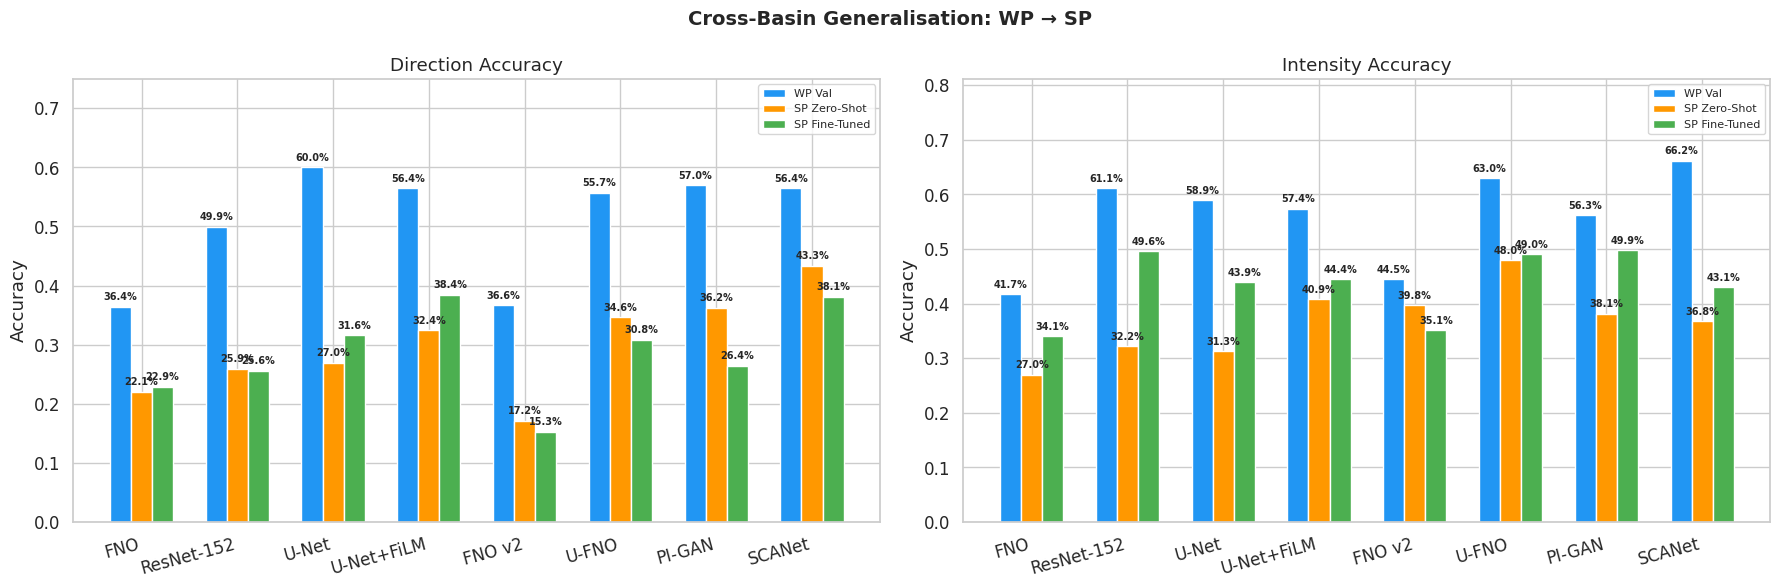

In [41]:
# ── Direction & Intensity accuracy: grouped bar chart ──
settings = ["WP Val", "SP Zero-Shot", "SP Fine-Tuned"]
colours  = ["#2196F3", "#FF9800", "#4CAF50"]
x = np.arange(len(MODEL_NAMES))
w = 0.22

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, metric, title in zip(
        axes, ["dir_acc", "int_acc"], ["Direction Accuracy", "Intensity Accuracy"]):
    for i, (setting, col) in enumerate(zip(settings, colours)):
        vals = [results[name][setting][metric] for name in MODEL_NAMES]
        bars = ax.bar(x + i * w, vals, w, label=setting, color=col, edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                    f"{v:.1%}", ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_xticks(x + w)
    ax.set_xticklabels(MODEL_NAMES, rotation=15, ha="right")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, max(results[n][s][metric]
                                 for n in MODEL_NAMES for s in settings) + 0.15))
    ax.legend(fontsize=8)

fig.suptitle("Cross-Basin Generalisation: WP → SP", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_accuracy_bars.png", dpi=200, bbox_inches="tight")
plt.show()

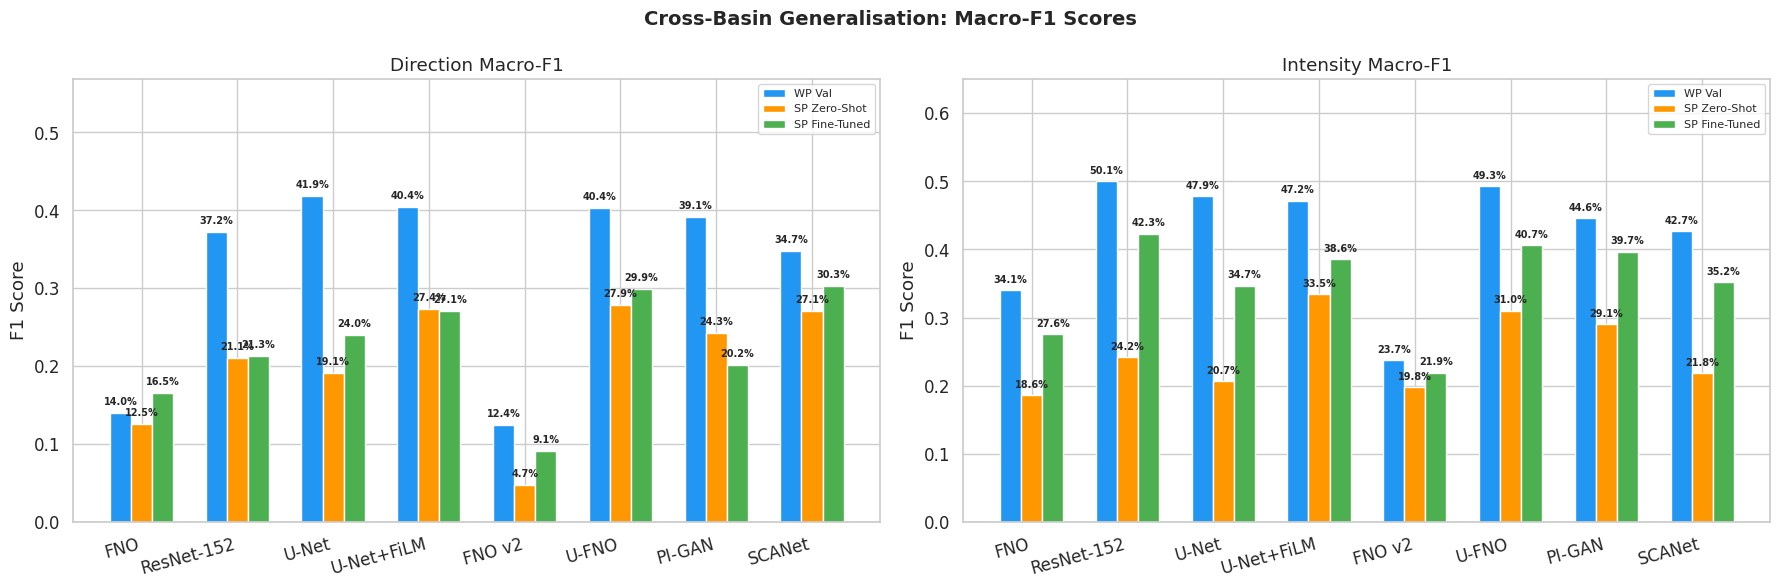

In [42]:
# ── Macro F1: grouped bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, metric, title in zip(
        axes, ["dir_f1", "int_f1"], ["Direction Macro-F1", "Intensity Macro-F1"]):
    for i, (setting, col) in enumerate(zip(settings, colours)):
        vals = [results[name][setting][metric] for name in MODEL_NAMES]
        bars = ax.bar(x + i * w, vals, w, label=setting, color=col, edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                    f"{v:.1%}", ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_xticks(x + w)
    ax.set_xticklabels(MODEL_NAMES, rotation=15, ha="right")
    ax.set_ylabel("F1 Score")
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, max(results[n][s][metric]
                                 for n in MODEL_NAMES for s in settings) + 0.15))
    ax.legend(fontsize=8)

fig.suptitle("Cross-Basin Generalisation: Macro-F1 Scores", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_f1_bars.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Confusion Matrices (SP Zero-Shot)

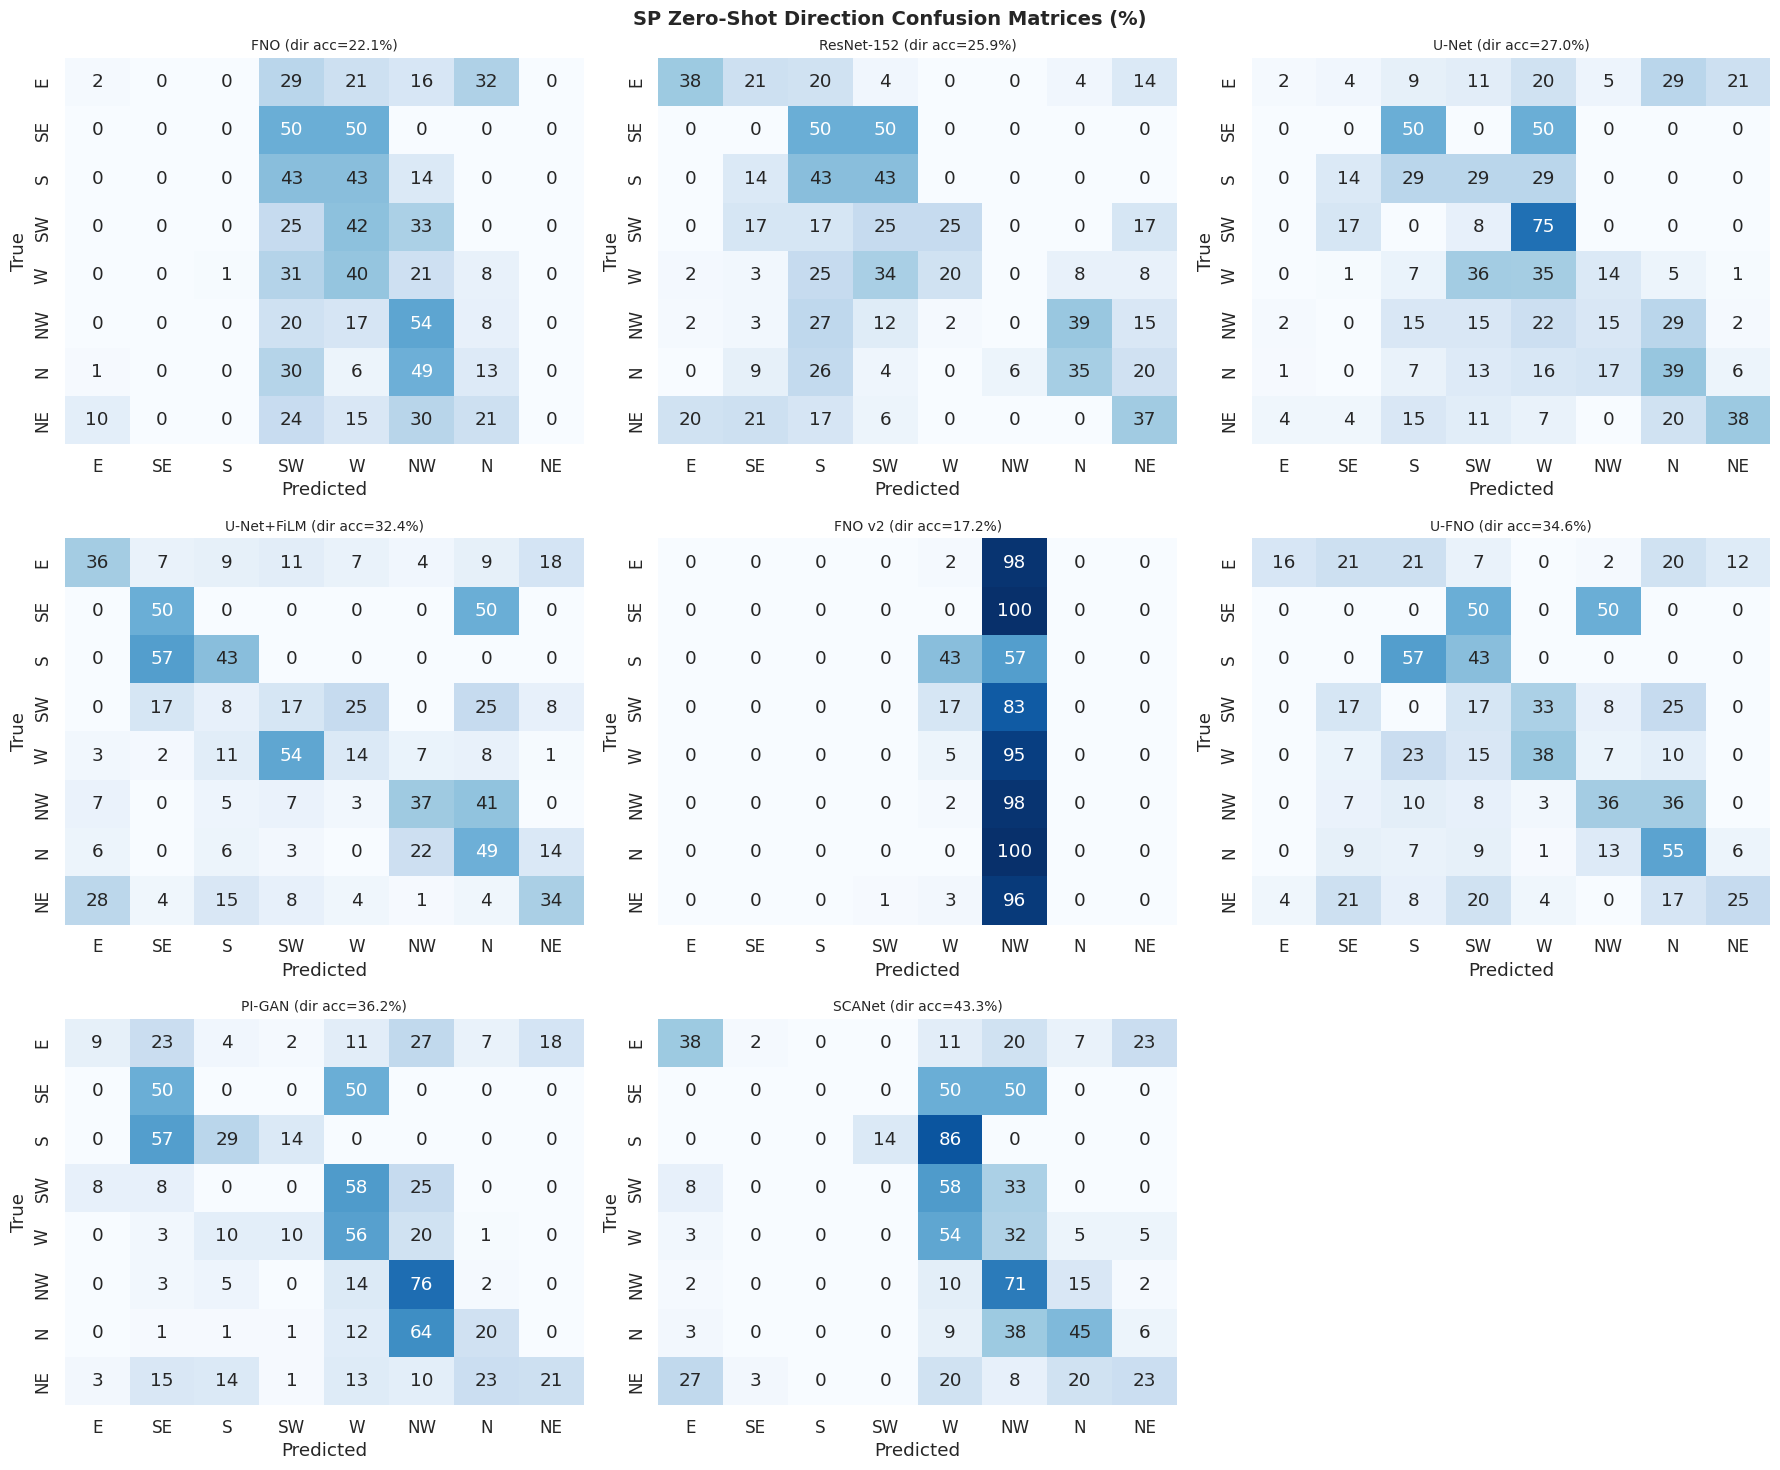

In [43]:
# ── Direction confusion matrices: zero-shot SP ──
n_models = len(MODEL_NAMES)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for ax, name in zip(axes[:n_models], MODEL_NAMES):
    m = results[name]["SP Zero-Shot"]
    cm = confusion_matrix(m["dir_trues"], m["dir_preds"], labels=range(N_DIR_CLASSES))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap="Blues",
                xticklabels=DIR_LABELS, yticklabels=DIR_LABELS,
                cbar=False, ax=ax, vmin=0, vmax=100)
    ax.set_title(f"{name} (dir acc={m['dir_acc']:.1%})", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle("SP Zero-Shot Direction Confusion Matrices (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_cm_dir_zeroshot.png", dpi=200, bbox_inches="tight")
plt.show()

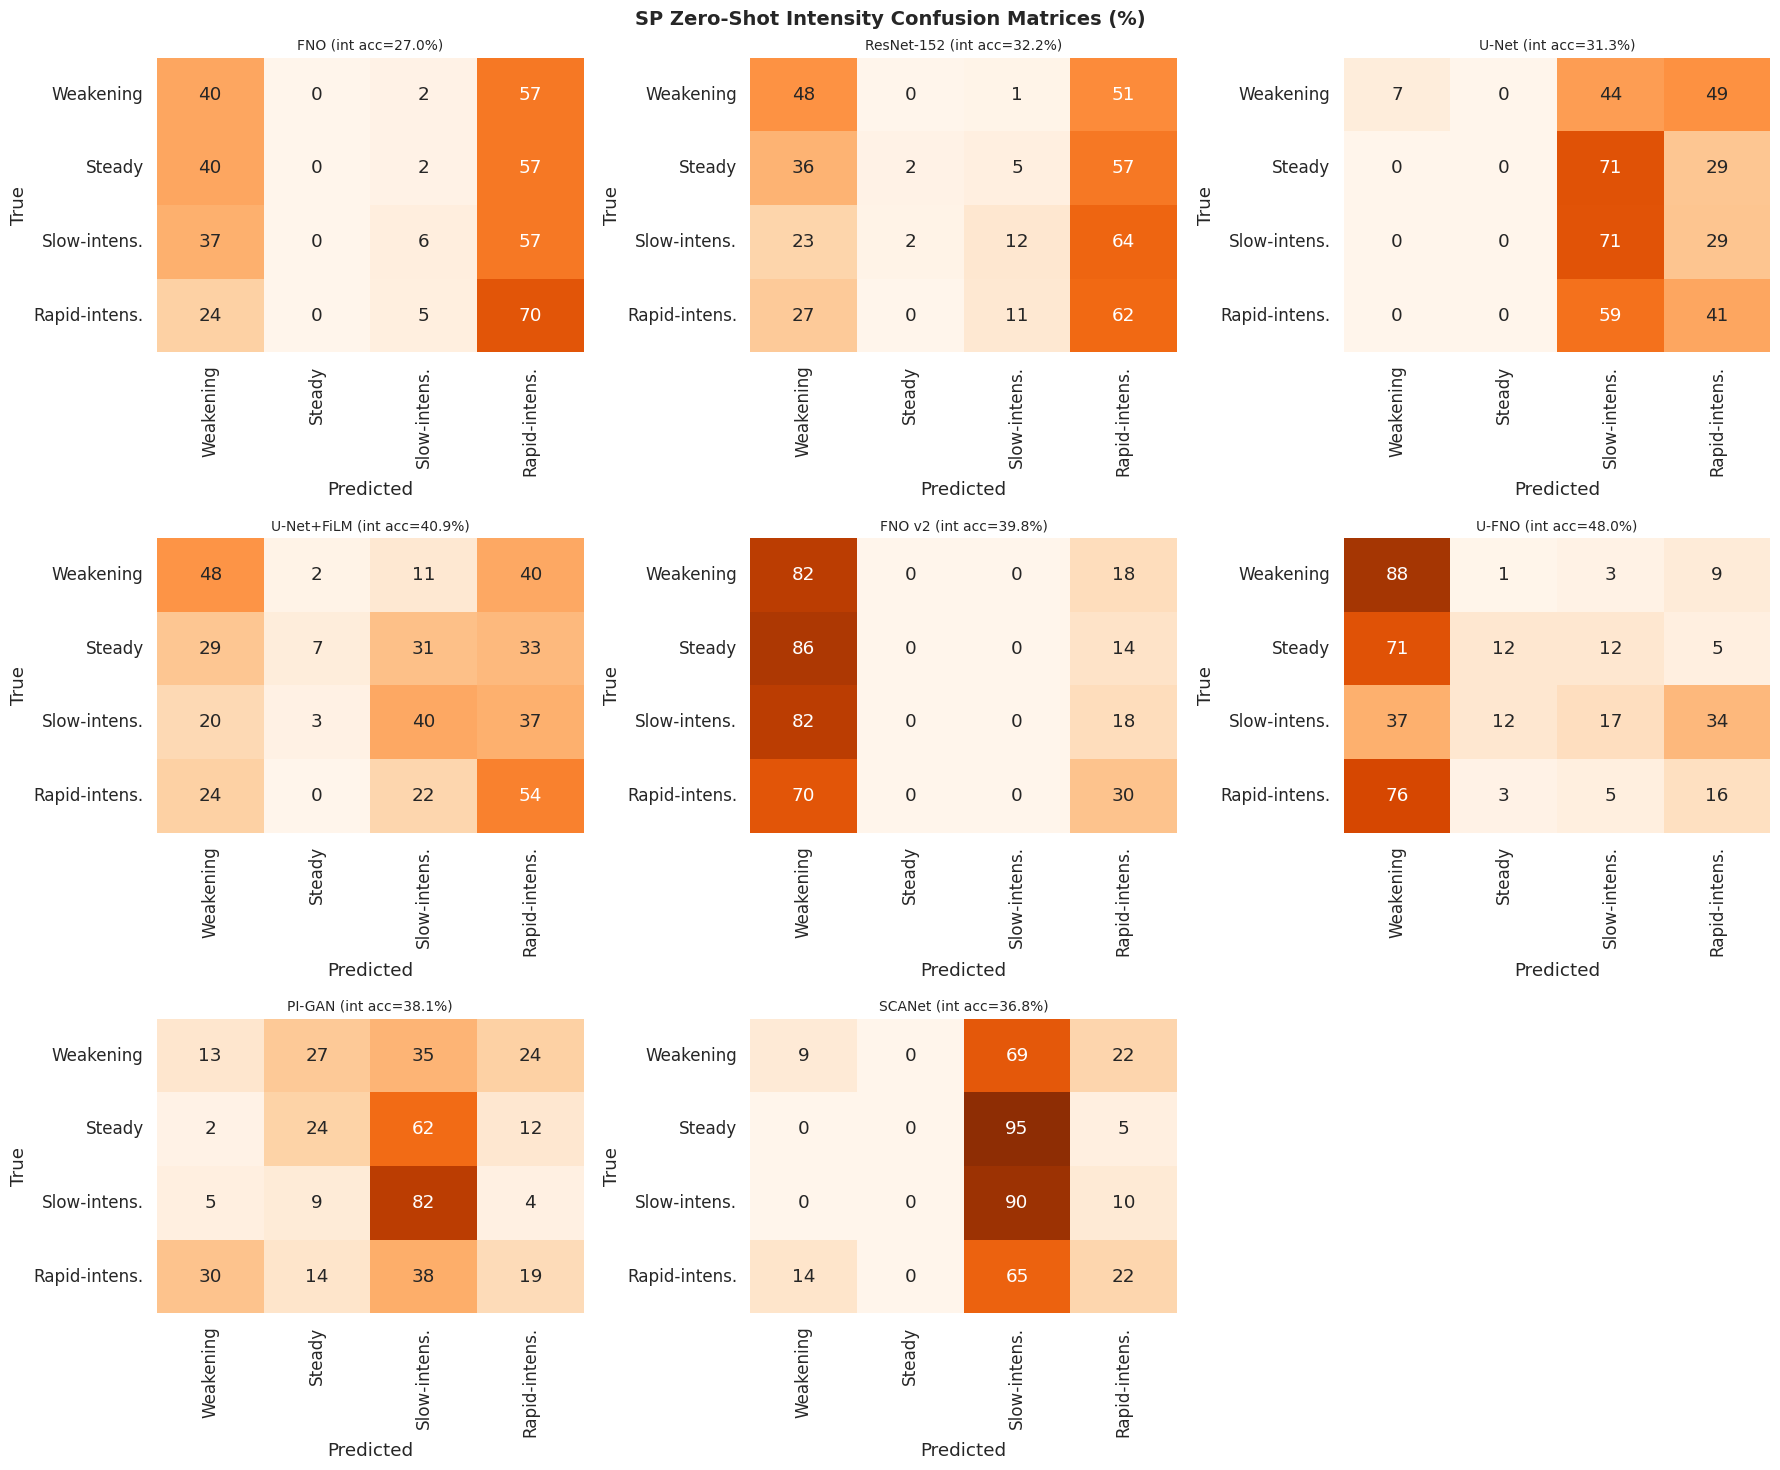

In [44]:
# ── Intensity confusion matrices: zero-shot SP ──
n_models = len(MODEL_NAMES)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for ax, name in zip(axes[:n_models], MODEL_NAMES):
    m = results[name]["SP Zero-Shot"]
    cm = confusion_matrix(m["int_trues"], m["int_preds"], labels=range(N_INT_CLASSES))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap="Oranges",
                xticklabels=INTE_LABELS, yticklabels=INTE_LABELS,
                cbar=False, ax=ax, vmin=0, vmax=100)
    ax.set_title(f"{name} (int acc={m['int_acc']:.1%})", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle("SP Zero-Shot Intensity Confusion Matrices (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_cm_int_zeroshot.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Fine-Tuning Impact

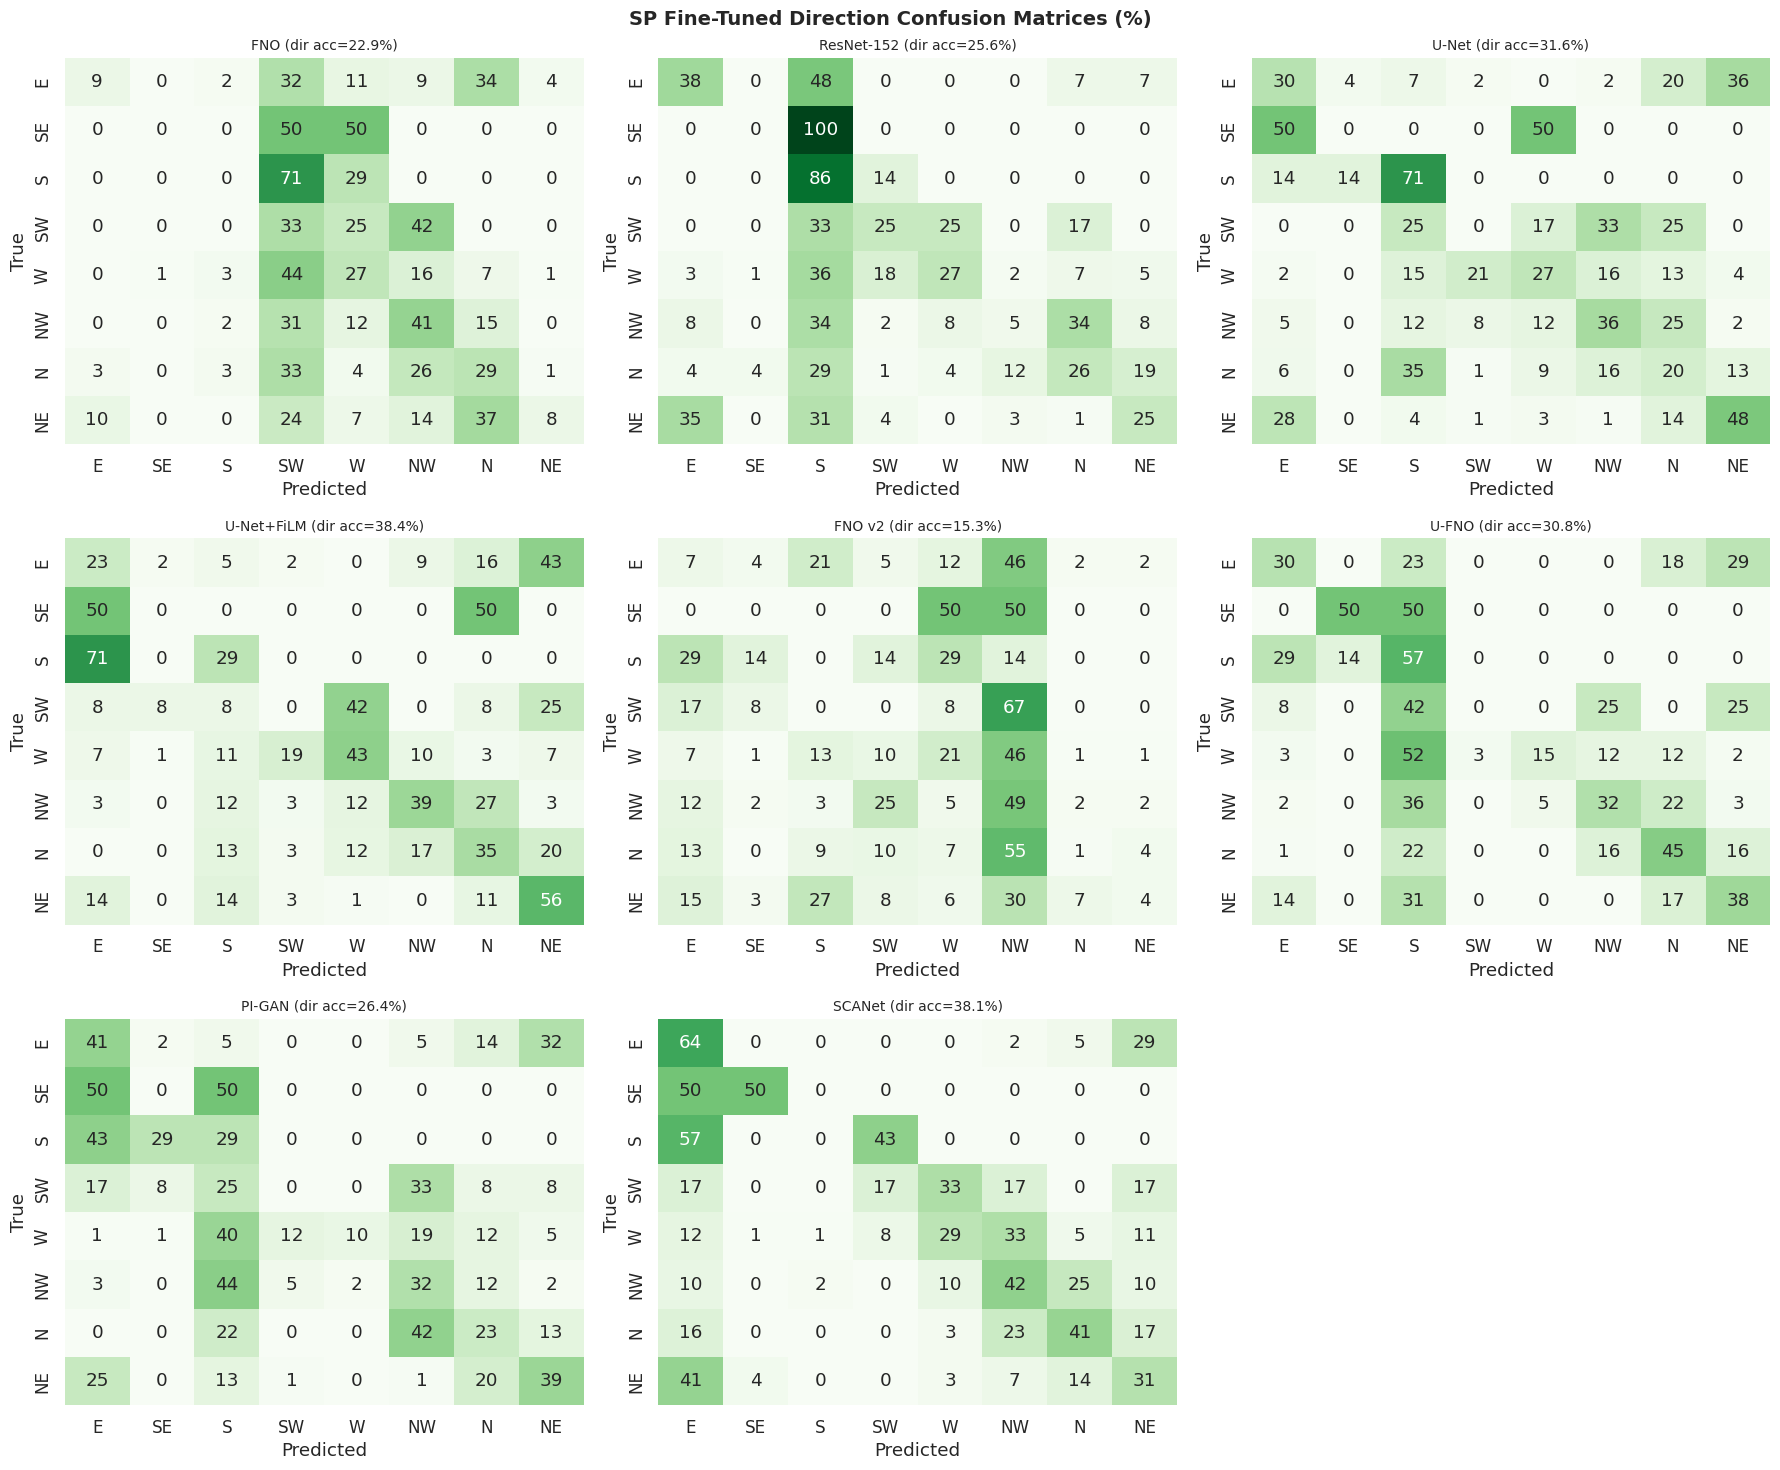

In [45]:
# ── Direction confusion matrices: fine-tuned SP ──
n_models = len(MODEL_NAMES)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for ax, name in zip(axes[:n_models], MODEL_NAMES):
    m = results[name]["SP Fine-Tuned"]
    cm = confusion_matrix(m["dir_trues"], m["dir_preds"], labels=range(N_DIR_CLASSES))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt=".0f", cmap="Greens",
                xticklabels=DIR_LABELS, yticklabels=DIR_LABELS,
                cbar=False, ax=ax, vmin=0, vmax=100)
    ax.set_title(f"{name} (dir acc={m['dir_acc']:.1%})", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle("SP Fine-Tuned Direction Confusion Matrices (%)", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_cm_dir_finetuned.png", dpi=200, bbox_inches="tight")
plt.show()

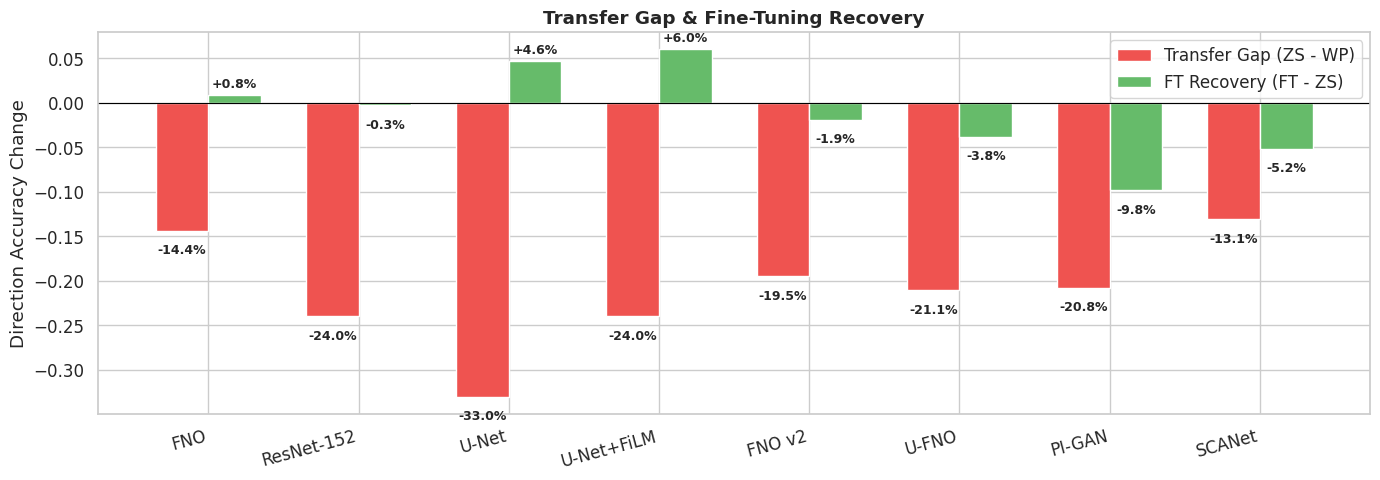

In [46]:
# ── Transfer gap waterfall chart ──
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(MODEL_NAMES))
w = 0.35

gaps = [results[n]["SP Zero-Shot"]["dir_acc"] - results[n]["WP Val"]["dir_acc"]
        for n in MODEL_NAMES]
recoveries = [results[n]["SP Fine-Tuned"]["dir_acc"] - results[n]["SP Zero-Shot"]["dir_acc"]
              for n in MODEL_NAMES]

bars1 = ax.bar(x - w/2, gaps, w, label="Transfer Gap (ZS - WP)",
               color="#EF5350", edgecolor="white")
bars2 = ax.bar(x + w/2, recoveries, w, label="FT Recovery (FT - ZS)",
               color="#66BB6A", edgecolor="white")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (0.005 if h >= 0 else -0.015),
                f"{h:+.1%}", ha="center", va="bottom" if h >= 0 else "top",
                fontsize=9, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, rotation=15, ha="right")
ax.set_ylabel("Direction Accuracy Change")
ax.set_title("Transfer Gap & Fine-Tuning Recovery", fontweight="bold")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_transfer_gap.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Per-Class F1 Comparison

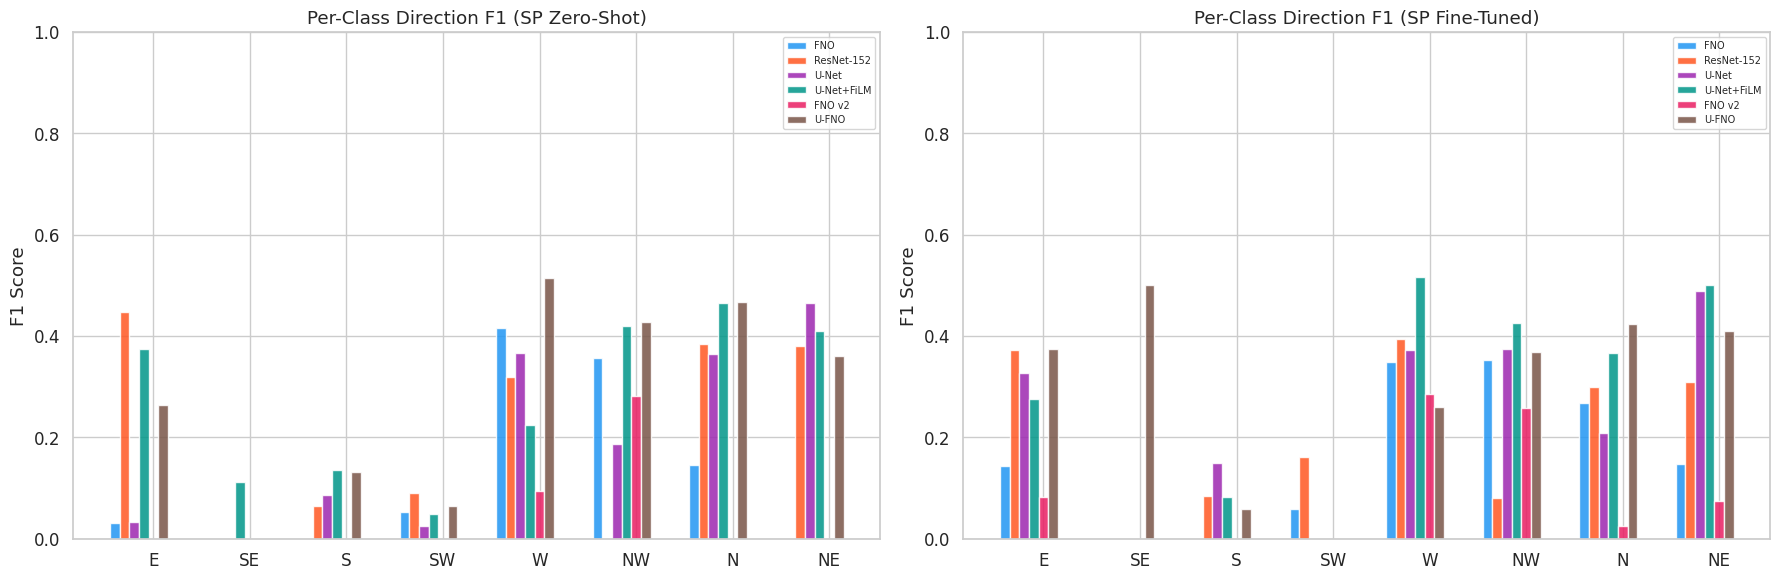

In [47]:
from sklearn.metrics import f1_score as f1_fn

# ── Per-class direction F1 on SP zero-shot ──
model_colours = ["#2196F3", "#FF5722", "#9C27B0", "#009688", "#E91E63", "#795548"]
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, setting, title in zip(axes, ["SP Zero-Shot", "SP Fine-Tuned"],
                               ["SP Zero-Shot", "SP Fine-Tuned"]):
    x_cls = np.arange(N_DIR_CLASSES)
    w_cls = 0.8 / len(MODEL_NAMES)
    for i, (name, col) in enumerate(zip(MODEL_NAMES, model_colours)):
        m = results[name][setting]
        per_f1 = f1_fn(m["dir_trues"], m["dir_preds"],
                        labels=range(N_DIR_CLASSES), average=None, zero_division=0)
        ax.bar(x_cls + i * w_cls, per_f1, w_cls, label=name, color=col,
               edgecolor="white", alpha=0.85)
    ax.set_xticks(x_cls + w_cls * len(MODEL_NAMES) / 2)
    ax.set_xticklabels(DIR_LABELS)
    ax.set_ylabel("F1 Score")
    ax.set_title(f"Per-Class Direction F1 ({title})")
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=7)

fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_perclass_f1.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Radar Chart: Multi-Metric Comparison

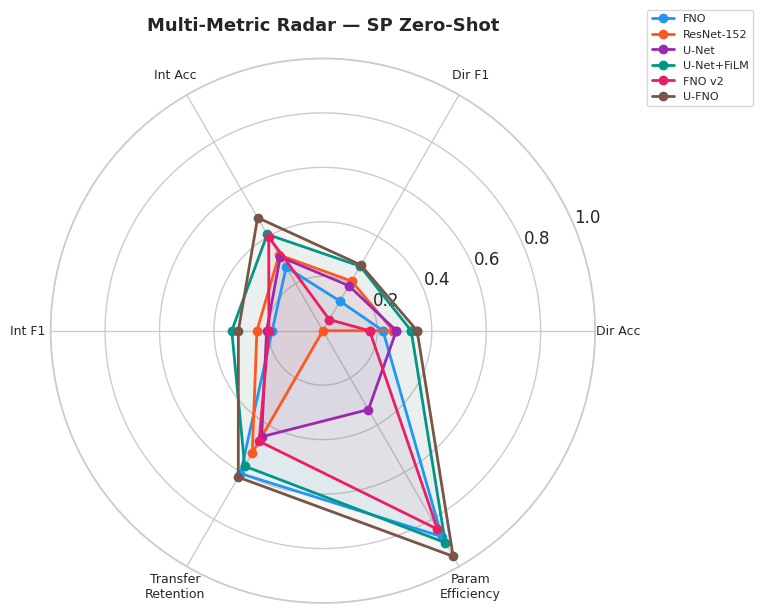

In [48]:
# ── Radar chart: 6 metrics per model (SP zero-shot) ──
metrics_radar = ["dir_acc", "dir_f1", "int_acc", "int_f1"]
metric_labels = ["Dir Acc", "Dir F1", "Int Acc", "Int F1"]
model_colours = ["#2196F3", "#FF5722", "#9C27B0", "#009688", "#E91E63", "#795548"]

param_counts = {}
for name, m in zip(MODEL_NAMES, wp_models):
    param_counts[name] = sum(p.numel() for p in m.parameters())
max_params = max(param_counts.values())

angles = np.linspace(0, 2 * np.pi, len(metric_labels) + 2, endpoint=False).tolist()
all_labels = metric_labels + ["Transfer\nRetention", "Param\nEfficiency"]
angles_closed = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, col in zip(MODEL_NAMES, model_colours):
    vals = [results[name]["SP Zero-Shot"][m] for m in metrics_radar]
    wp_dir = results[name]["WP Val"]["dir_acc"]
    sp_dir = results[name]["SP Zero-Shot"]["dir_acc"]
    transfer_retention = sp_dir / wp_dir if wp_dir > 0 else 0
    vals.append(transfer_retention)
    vals.append(1 - param_counts[name] / max_params)
    vals_closed = vals + [vals[0]]
    ax.plot(angles_closed, vals_closed, "o-", label=name, color=col, linewidth=2)
    ax.fill(angles_closed, vals_closed, alpha=0.05, color=col)

ax.set_xticks(angles)
ax.set_xticklabels(all_labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Multi-Metric Radar — SP Zero-Shot", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_radar.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Classification Reports

In [49]:
# ── Detailed classification reports (SP zero-shot) ──
for name in MODEL_NAMES:
    m = results[name]["SP Zero-Shot"]
    print(f"\n{'='*60}")
    print(f" {name} — SP Zero-Shot Direction")
    print(f"{'='*60}")
    print(classification_report(
        m["dir_trues"], m["dir_preds"],
        target_names=DIR_LABELS, zero_division=0))

    print(f" {name} — SP Zero-Shot Intensity")
    print(f"{'-'*60}")
    print(classification_report(
        m["int_trues"], m["int_preds"],
        target_names=INTE_LABELS, zero_division=0))


 FNO — SP Zero-Shot Direction
              precision    recall  f1-score   support

           E       0.11      0.02      0.03        56
          SE       0.00      0.00      0.00         2
           S       0.00      0.00      0.00         7
          SW       0.03      0.25      0.05        12
           W       0.44      0.40      0.42        91
          NW       0.27      0.54      0.36        59
           N       0.17      0.13      0.15        69
          NE       0.00      0.00      0.00        71

    accuracy                           0.22       367
   macro avg       0.13      0.17      0.13       367
weighted avg       0.20      0.22      0.19       367

 FNO — SP Zero-Shot Intensity
------------------------------------------------------------
               precision    recall  f1-score   support

    Weakening       0.48      0.40      0.44       164
       Steady       0.00      0.00      0.00        42
 Slow-intens.       0.50      0.06      0.10       124
Rapid-

## 12. Summary & Key Findings

In [50]:
# ── Final summary table ──
print("\n" + "=" * 90)
print(" FINAL COMPARISON SUMMARY")
print("=" * 90)
print(f"{'Model':12s} | {'Params':>10s} | {'WP Dir':>7s} | {'SP-ZS Dir':>9s} | "
      f"{'Gap':>6s} | {'SP-FT Dir':>9s} | {'Recovery':>8s}")
print("-" * 90)

for name in MODEL_NAMES:
    wp  = results[name]["WP Val"]["dir_acc"]
    zs  = results[name]["SP Zero-Shot"]["dir_acc"]
    ft  = results[name]["SP Fine-Tuned"]["dir_acc"]
    n_p = f"{param_counts[name]:,d}"
    print(f"{name:12s} | {n_p:>10s} | {wp:>6.1%} | {zs:>8.1%} | "
          f"{zs-wp:>+5.1%} | {ft:>8.1%} | {ft-zs:>+7.1%}")

print("=" * 90)

# ── Identify best model ──
best_zs = max(MODEL_NAMES, key=lambda n: results[n]["SP Zero-Shot"]["dir_acc"])
best_ft = max(MODEL_NAMES, key=lambda n: results[n]["SP Fine-Tuned"]["dir_acc"])
best_eff = min(MODEL_NAMES, key=lambda n: (
    -results[n]["SP Zero-Shot"]["dir_acc"] / (param_counts[n] / 1e6)))

print(f"\nBest zero-shot transfer:  {best_zs}")
print(f"Best after fine-tuning:   {best_ft}")
print(f"Best param efficiency:    {best_eff} "
      f"({results[best_eff]['SP Zero-Shot']['dir_acc']:.1%} with "
      f"{param_counts[best_eff]/1e6:.1f}M params)")


 FINAL COMPARISON SUMMARY
Model        |     Params |  WP Dir | SP-ZS Dir |    Gap | SP-FT Dir | Recovery
------------------------------------------------------------------------------------------
FNO          |  7,424,588 |  36.4% |    22.1% | -14.4% |    22.9% |   +0.8%
ResNet-152   | 58,696,140 |  49.9% |    25.9% | -24.0% |    25.6% |   -0.3%
U-Net        | 39,070,052 |  60.0% |    27.0% | -33.0% |    31.6% |   +4.6%
U-Net+FiLM   |  5,930,928 |  56.4% |    32.4% | -24.0% |    38.4% |   +6.0%
FNO v2       |  9,292,524 |  36.6% |    17.2% | -19.5% |    15.3% |   -1.9%
U-FNO        |  2,536,770 |  55.7% |    34.6% | -21.1% |    30.8% |   -3.8%
PI-GAN       | 10,033,864 |  57.0% |    36.2% | -20.8% |    26.4% |   -9.8%
SCANet       |  3,704,726 |  56.4% |    43.3% | -13.1% |    38.1% |   -5.2%

Best zero-shot transfer:  SCANet
Best after fine-tuning:   U-Net+FiLM
Best param efficiency:    U-FNO (34.6% with 2.5M params)


In [51]:
# ── Save all figures list ──
print("\nFigures saved:")
for f in sorted(FIG_DIR.glob("comparison_*.png")):
    print(f"  {f.name}")


Figures saved:
  comparison_accuracy_bars.png
  comparison_cm_dir_finetuned.png
  comparison_cm_dir_zeroshot.png
  comparison_cm_int_zeroshot.png
  comparison_f1_bars.png
  comparison_perclass_f1.png
  comparison_radar.png
  comparison_transfer_gap.png
